## **Introdução**

## **Descrição**

Este dataset mostra o ranking dos melhores animes de acordo com a votação dos membros do site MyAnimeList.net. Os animes são classificados em ordem decrescente, do melhor para o pior, com base nas pontuações fornecidas pelos usuários.



## **Colunas**

**UID** : Identificador único para cada entrada de anime.

**Title** : Título da série de anime.

**Rank**: Classificação baseada nas avaliações e popularidade dos usuários.

**Stream type** : Tipo de disponibilidade de transmissão.

**Episodes** : Número de episódios da série.

**Start date** : Data de lançamento inicial do anime.

**End date** : Data de exibição final do anime.

**Members** : Número de membros da comunidade que adicionaram o anime às suas listas.

**Score** : Pontuação média de classificação do usuário para o anime.


Fonte:
https://myanimelist.net/





## **Insights Potenciais**



**Insight**: Identificar quais características (número de episódios, número de membros, pontuação, datas de início e término) são mais importantes para determinar o tipo de transmissão de um anime.

**Utilidade**: Isso pode ajudar produtores e distribuidores de animes a entender melhor como certas características influenciam a forma como um anime é lançado e distribuído, podendo orientar estratégias de marketing e lançamento.
Distribuição de Tipos de Transmissão

**Insight**: Analisar a distribuição dos diferentes tipos de transmissão (TV, OVA, Filme, etc.) no dataset.

**Utilidade**: Entender a proporção de diferentes formatos pode ajudar na tomada de decisões sobre investimentos em novos projetos de animes, focando em formatos mais populares ou explorando formatos menos comuns.
Previsão do Tipo de Transmissão para Novos Animes




**Insight**: Usar um modelo treinado para prever o tipo de transmissão de novos animes com base em suas características.

**Utilidade**: Novos criadores de conteúdo podem usar essas previsões para decidir o melhor formato para lançar suas produções, com base em características semelhantes a animes já existentes.
Comparação de Modelos de Classificação


**Insight**: Comparar a performance de diferentes modelos de machine learning (Logistic Regression, Decision Tree, Random Forest, SVM) na tarefa de classificação.

**Utilidade**: Identificar o modelo mais eficaz para este tipo de tarefa pode ajudar a melhorar a precisão das previsões e a eficiência do processo de classificação.
Segmentação de Animes com Base em Características Similares




**Insight**: Agrupar animes em clusters com características semelhantes e analisar os tipos de transmissão mais comuns dentro de cada cluster.

**Utilidade**: Pode revelar subcategorias ou segmentos de animes que têm características similares e que podem ser explorados de forma mais estratégica.


## **Importação das Bibliotecas**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import datasets
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, ConfusionMatrixDisplay
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor





## **Carregando o Dataset**

In [2]:
df = pd.read_csv('/content/Anime_rank.csv')
df.head()


,UID,Title,Rank,Stream type,Episodes,Start date,End date,Members,Score
0,1,Sousou no Frieren,1,TV,28.0,Sep 2023,Mar 2024,"800,615",9.35
1,2,Fullmetal Alchemist: Brotherhood,2,TV,64.0,Apr 2009,Jul 2010,"3,373,923",9.09
2,3,Steins;Gate,3,TV,24.0,Apr 2011,Sep 2011,"2,584,616",9.07
3,4,Gintama°,4,TV,51.0,Apr 2015,Mar 2016,"636,631",9.06
4,5,Shingeki no Kyojin Season 3 Part 2,5,TV,10.0,Apr 2019,Jul 2019,"2,305,044",9.05


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8650 entries, 0 to 8649
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   UID          8650 non-null   int64  
 1   Title        8650 non-null   object 
 2   Rank         8650 non-null   int64  
 3   Stream type  8650 non-null   object 
 4   Episodes     8608 non-null   float64
 5   Start date   8648 non-null   object 
 6   End date     8551 non-null   object 
 7   Members      8650 non-null   object 
 8   Score        8650 non-null   float64
dtypes: float64(2), int64(2), object(5)
memory usage: 608.3+ KB


## **Tratando os Dados**

In [4]:
#Excluindo as linhas com valores ausentes do dataframe
missing_values = df.isnull().sum()
print(missing_values)

df.dropna(inplace=True)

print(df.isnull().sum())

UID             0
Title           0
Rank            0
Stream type     0
Episodes       42
Start date      2
End date       99
Members         0
Score           0
dtype: int64
UID            0
Title          0
Rank           0
Stream type    0
Episodes       0
Start date     0
End date       0
Members        0
Score          0
dtype: int64


In [5]:
# Excluindo a coluna UID, pois, não irei utiliza-la nesse projeto
dados = df.drop('UID', axis= 1)
dados.head()


,Title,Rank,Stream type,Episodes,Start date,End date,Members,Score
0,Sousou no Frieren,1,TV,28.0,Sep 2023,Mar 2024,"800,615",9.35
1,Fullmetal Alchemist: Brotherhood,2,TV,64.0,Apr 2009,Jul 2010,"3,373,923",9.09
2,Steins;Gate,3,TV,24.0,Apr 2011,Sep 2011,"2,584,616",9.07
3,Gintama°,4,TV,51.0,Apr 2015,Mar 2016,"636,631",9.06
4,Shingeki no Kyojin Season 3 Part 2,5,TV,10.0,Apr 2019,Jul 2019,"2,305,044",9.05


## **Explorando os Dados**

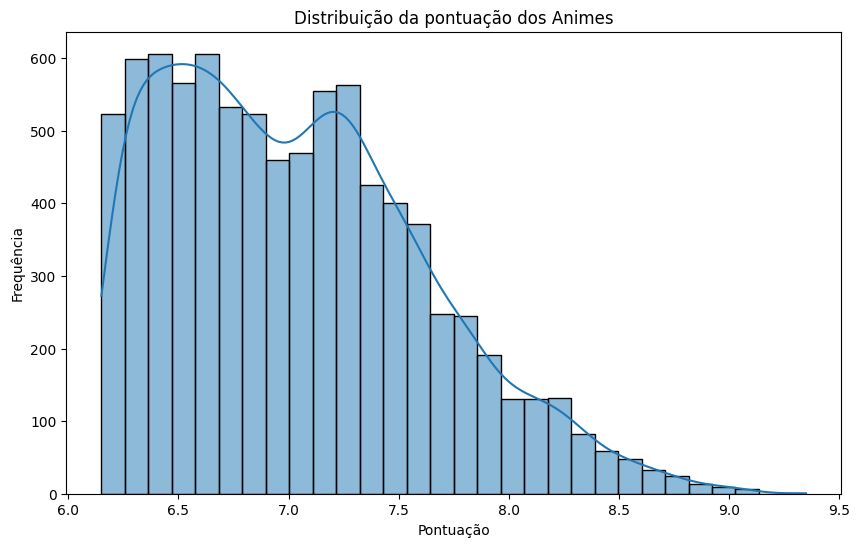

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(dados['Score'], bins=30, kde=True)
plt.title('Distribuição da pontuação dos Animes')
plt.xlabel('Pontuação')
plt.ylabel('Frequência')
plt.show()

In [7]:
fig = px.histogram(dados, x= 'Stream type', text_auto = True)
fig.update_layout(
    title='Distribuição do Tipo de Transmissão',
    xaxis_title='Tipo de Transmissão',
    yaxis_title='Contagem'
)
fig.show()

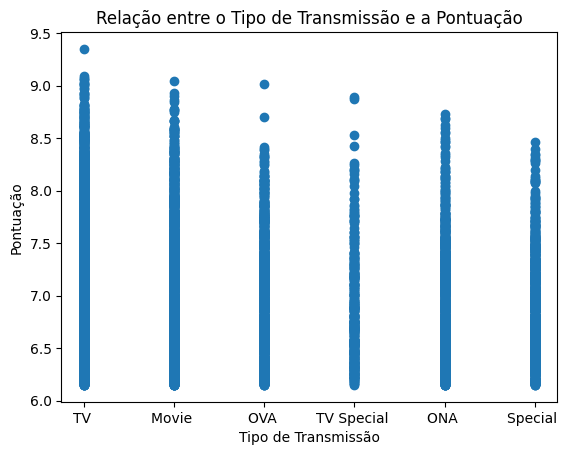

In [8]:
plt.scatter(dados['Stream type'], dados['Score'])
plt.xlabel('Tipo de Transmissão')
plt.ylabel('Pontuação')
plt.title('Relação entre o Tipo de Transmissão e a Pontuação')
plt.show()

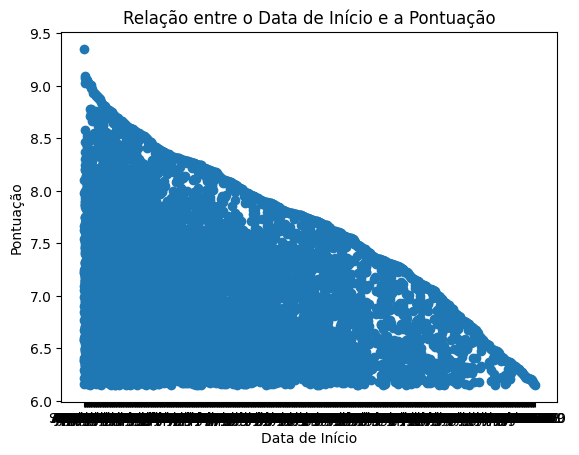

In [9]:
plt.scatter(dados['Start date'], dados['Score'])
plt.xlabel('Data de Início')
plt.ylabel('Pontuação')
plt.title('Relação entre o Data de Início e a Pontuação')
plt.show()

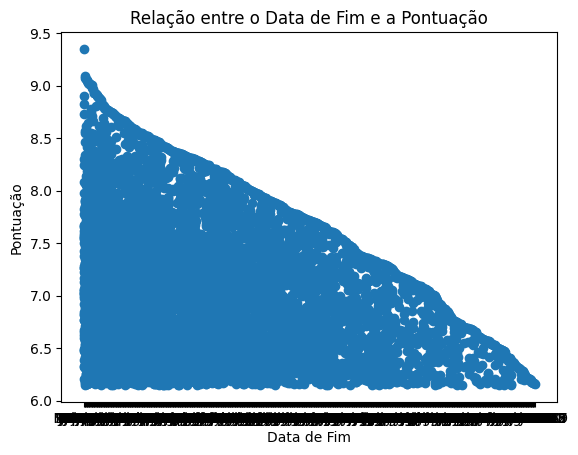

In [10]:
plt.scatter(dados['End date'], dados['Score'])
plt.xlabel('Data de Fim')
plt.ylabel('Pontuação')
plt.title('Relação entre o Data de Fim e a Pontuação')
plt.show()

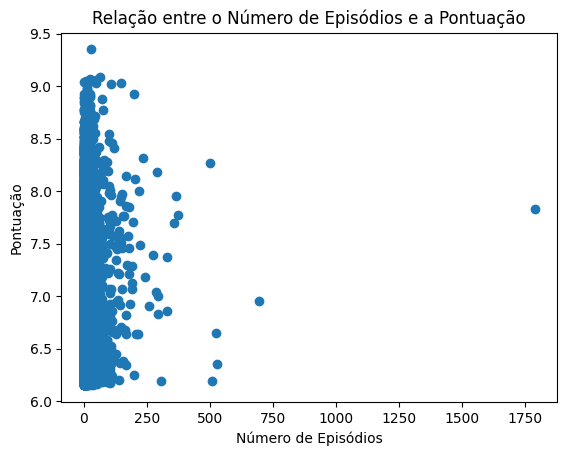

In [11]:
plt.scatter(dados['Episodes'], dados['Score'])
plt.xlabel('Número de Episódios')
plt.ylabel('Pontuação')
plt.title('Relação entre o Número de Episódios e a Pontuação')
plt.show()

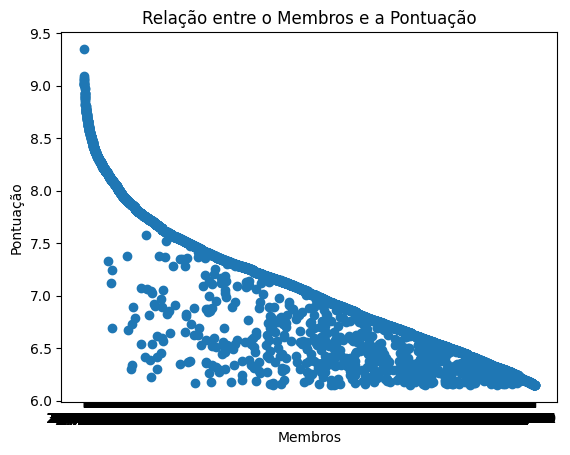

In [12]:
plt.scatter(dados['Members'], dados['Score'])
plt.xlabel('Membros')
plt.ylabel('Pontuação')
plt.title('Relação entre o Membros e a Pontuação')
plt.show()

## **Transformando os Dados**

In [13]:
# converter a coluna categórica Stream type em valores numéricos
label_encoder = LabelEncoder()
dados['Stream type'] = label_encoder.fit_transform(dados['Stream type'])

# Converter a coluna 'Members' para numérica, removendo vírgulas e convertendo para float
dados['Members'] = dados['Members'].str.replace(',', '').astype(float)

# Separar Recursos (features) e Alvo (target)
X = dados[['Episodes', 'Members', 'Stream type']]
y = dados['Score']

# Padronização dos Dados para X_norm
sc = StandardScaler()
X_norm = sc.fit_transform(X)

# Separando em Dados de Treino e Dados de Teste;  Teste em 20%
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2)

## **Modelos de Treinamento**

### **Multi-Layer Perceptron, MLP Regressor**

In [14]:
#MLPRegressor usa-se para regressão, onde a variável alvo é contínua (por exemplo, preços de casas, temperaturas).
mlp = MLPRegressor(hidden_layer_sizes=(100,), max_iter=200)

In [15]:
mlp.fit(X_train, y_train)

MLPRegressor()

In [16]:
preds_mlp = mlp.predict(X_test)

In [17]:
# Calcula a Acurácia
acuracia_mlp = mlp.score(X_test, y_test)
print(f'Acurácia MLP: ', acuracia_mlp)

Acurácia MLP:  0.3963067114529688


In [18]:
# Calcula o Erro Quadrático Médio
mse_mlp = mean_squared_error(y_test, preds_mlp)
print("Erro Quadrático Médio MLP:", mse_mlp)

Erro Quadrático Médio MLP: 0.21302805468992003


In [19]:
# Calcula o R² Score
r2_mlp = r2_score(y_test, preds_mlp)
print(f'R² Score MLP: ', r2_mlp)

R² Score MLP:  0.3963067114529688


### **Regressão Linear**

In [20]:
reg_model = LinearRegression()

In [21]:
reg_model.fit(X_train, y_train)

LinearRegression()

In [22]:
preds_reg = reg_model.predict(X_test)

In [23]:
# Calcula a Acurácia
acuracia_reg = reg_model.score(X_test, y_test)
print(f'Acurácia Regressão Linear: ', acuracia_reg)

Acurácia Regressão Linear:  0.19460769271350464


In [24]:
# Calcula o Erro Quadrático Médio
mse_reg = mean_squared_error(y_test, preds_reg, squared=False)
print("Erro Quadrático Médio Regressão Linear :", mse_reg)

Erro Quadrático Médio Regressão Linear : 0.5331064849158251


In [25]:
# Calcula o R² Score
r2_reg = r2_score(y_test, preds_reg)
print(f'R² Score Regressão Linear: ', r2_reg)

R² Score Regressão Linear:  0.19460769271350464


### **K-Nearest Neighbors Regressor**

In [26]:
normalizacao = MinMaxScaler()
x_treino_normalizado = normalizacao.fit_transform(X_train)

In [27]:
#KNeighborsRegressor usa-se para regressão, onde a variável alvo é contínua (por exemplo, preços de casas, temperaturas).
knn = KNeighborsRegressor()

In [28]:
knn.fit(x_treino_normalizado, y_train)

KNeighborsRegressor()

In [29]:
x_teste_normalizado = normalizacao.transform(X_test)

In [30]:
preds_knn = knn.predict(x_teste_normalizado)

In [31]:
# Calcula a Acurácia
acuracia_knn = knn.score(x_teste_normalizado, y_test)
print(f'Acurácia KNN: ', acuracia_knn)

Acurácia KNN:  0.3454428949992179


In [32]:
# Calcula o Erro Quadrático Médio
mse_knn = mean_squared_error(y_test, preds_knn, squared=False)
print("Erro Quadrático Médio KNN:", mse_knn)

Erro Quadrático Médio KNN: 0.480600255771835


In [33]:
# Calcula o R² Score
r2_knn = r2_score(y_test, preds_knn)
print(f'R² Score KNN: ', r2_knn)

R² Score KNN:  0.3454428949992179


### **Árvore de Decisão**

In [34]:
#DecisionTreeRegressor usa-se para regressão, onde a variável alvo é contínua (por exemplo, preços de casas, temperaturas).
tree = DecisionTreeRegressor()

In [35]:
tree.fit(X_train, y_train)

DecisionTreeRegressor()

In [36]:
preds_tree = tree.predict(X_test)

In [37]:
# Calcula a Acurácia
acuracia_tree = tree.score(X_test, y_test)
print(f'Acurácia Árvore de Decisão: ', acuracia_tree)

Acurácia Árvore de Decisão:  -0.0935581606370337


In [38]:
# Calcula o Erro Quadrático Médio
mse_tree = mean_squared_error(y_test, preds_tree, squared=False)
print("Erro Quadrático Médio Árvore de Decisão:", mse_tree)

Erro Quadrático Médio Árvore de Decisão: 0.6211996034837926


In [39]:
# Calcula o R² Score
r2_tree = r2_score(y_test, preds_tree)
print(f'R² Score Árvore de Decisão: ', r2_tree)

R² Score Árvore de Decisão:  -0.0935581606370337


### **SVR (Support Vector Regression)**

In [40]:
#SVR usa-se para regressão, onde a variável alvo é contínua (por exemplo, preços de casas, temperaturas).
svr = SVR()

In [41]:
svr.fit(X_train, y_train)

SVR()

In [42]:
predssvr = svr.predict(X_test)

In [43]:
# Calcula a Acurácia
acuracia_svr = svr.score(X_test, y_test)
print(f'Acurácia SVR: ', acuracia_svr)

Acurácia SVR:  0.36206764325074725


In [44]:
# Calcula o Erro Quadrático Médio
mse_svr = mean_squared_error(y_test, predssvr, squared=False)
print("Erro Quadrático Médio SVR:", mse_svr)

Erro Quadrático Médio SVR: 0.4744577470290166


In [45]:
# Calcula o R² Score
r2_svr = r2_score(y_test, predssvr)
print(f'R² Score SVR: ', r2_svr)


R² Score SVR:  0.36206764325074725


### **Random Forest Regression**

In [46]:
#RandomForestRegressor usa-se para regressão, onde a variável alvo é contínua (por exemplo, preços de casas, temperaturas).
rf = RandomForestRegressor(n_estimators=100, random_state=42)

In [47]:
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [48]:
preds_rf = rf.predict(X_test)

In [49]:
# Calcula a Acurácia
acuracia_rf = rf.score(X_test, y_test)
print(f'Acurácia Random Forest: ', acuracia_rf)

Acurácia Random Forest:  0.27183910026867164


In [50]:
# Calcula o Erro Quadrático Médio
mse_rf = mean_squared_error(y_test, preds_rf, squared=False)
print("Erro Quadrático Médio Random Forest:", mse_rf)

Erro Quadrático Médio Random Forest: 0.5069018827745397


In [51]:
# Calcula o R² Score
r2_rf = r2_score(y_test, preds_rf)
print(f'R² Score Random Forest: ', r2_rf)

R² Score Random Forest:  0.27183910026867164


## **Validando os Modelos**

### **Acurácia**

In [52]:
# A acurácia é uma métrica adequada para problemas de classificação, mas não para modelos de regressão.
# As melhores métricas para este modelo são o Erro Quadrático Médio e o R² Score.
# Para fins de estudo, mesmo assim, apresentarei as métricas abaixo.
print(f'Acurácia MLP: ', acuracia_mlp)
print(f'Acurácia Regressão Linear: ', acuracia_reg)
print(f'Acurácia KNN: ', acuracia_knn)
print(f'Acurácia Árvore de Decisão: ', acuracia_tree)
print(f'Acurácia SVR: ', acuracia_svr)
print(f'Acurácia Random Forest: ', acuracia_rf)

Acurácia MLP:  0.3963067114529688
Acurácia Regressão Linear:  0.19460769271350464
Acurácia KNN:  0.3454428949992179
Acurácia Árvore de Decisão:  -0.0935581606370337
Acurácia SVR:  0.36206764325074725
Acurácia Random Forest:  0.27183910026867164


### **Erro Quadrático Médio**

In [53]:
# Quanto mais próximo de 0 melhor é o modelo

print("Erro Quadrático Médio MLP:", mse_mlp)
print("Erro Quadrático Médio Regressão Linear :", mse_reg)
print("Erro Quadrático Médio KNN:", mse_knn)
print("Erro Quadrático Médio Árvore de Decisão:", mse_tree)
print("Erro Quadrático Médio SVR:", mse_svr)
print("Erro Quadrático Médio Random Forest:", mse_rf)

Erro Quadrático Médio MLP: 0.21302805468992003
Erro Quadrático Médio Regressão Linear : 0.5331064849158251
Erro Quadrático Médio KNN: 0.480600255771835
Erro Quadrático Médio Árvore de Decisão: 0.6211996034837926
Erro Quadrático Médio SVR: 0.4744577470290166
Erro Quadrático Médio Random Forest: 0.5069018827745397


### **R² Score**

In [54]:
# Quanto mais próximo de 1, melhor é o modelo. Um valor negativo indica um ajuste muito ruim dos dados pelo modelo.

print(f'R² Score MLP: ', r2_mlp)
print(f'R² Score Regressão Linear: ', r2_reg)
print(f'R² Score KNN: ', r2_knn)
print(f'R² Score Árvore de Decisão: ', r2_tree)
print(f'R² Score SVR: ', r2_svr)
print(f'R² Score Random Forest: ', r2_rf)

R² Score MLP:  0.3963067114529688
R² Score Regressão Linear:  0.19460769271350464
R² Score KNN:  0.3454428949992179
R² Score Árvore de Decisão:  -0.0935581606370337
R² Score SVR:  0.36206764325074725
R² Score Random Forest:  0.27183910026867164


## **Conclusão**

Com base nessas métricas:

Melhor R² Score: MLP com 0.396.
Menor Erro Quadrático Médio: MLP com 0.213.
Portanto, considerando ambas as métricas, o MLP (Multi-layer Perceptron) parece ser o melhor modelo entre os avaliados. Ele apresenta o maior R² Score e o menor Erro Quadrático Médio, indicando um melhor ajuste aos dados e uma capacidade superior de previsão em comparação com os outros modelos avaliados.






